## Flow Calibration

### Read the files and extract rpm data and calculate integrated flow at each rpm
Inside the folder, there should be pre-defined-name data files at different revolution(rpm) 

In [ ]:
# Prefer interactive backend for zoom/pan/reset toolbar in VS Code notebooks.
# Falls back to inline if ipympl/widget backend is unavailable.
ip = get_ipython()
matplotlib_backend = "inline"
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "widget")
        matplotlib_backend = "widget"
    except Exception:
        ip.run_line_magic("matplotlib", "inline")
        matplotlib_backend = "inline"
print(f"Matplotlib backend: {matplotlib_backend}")


from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# class for storing pump data
class PumpData:
    def __init__(self, pump_number, rpm_values, integrated_flow):
        self.pump_number = pump_number
        self.rpm_values = rpm_values
        self.integrated_flow = integrated_flow
        self.cooefficients = []
        self.r_squared = None

# Find the data file in the folder
DATA_FOLDER = ["pump_1", "pump_3", "pump_4"]

# set up the storage for pump data
pump_storage = []

for i, folder in enumerate(DATA_FOLDER):
    if not Path(folder).exists():
        raise FileNotFoundError(f"Data folder '{folder}' does not exist.")
    # extract pump number from folder name
    match = re.search(r"pump_(\d+)", folder)
    if not match:
        raise ValueError(f"Could not find pump number in folder name: {folder}")
    pump_number = match.group(1)

    pump_data = PumpData(pump_number, [], [])
    pump_storage.append(pump_data)

for folder in DATA_FOLDER:
    if not Path(folder).exists():
        raise FileNotFoundError(f"Data folder '{folder}' does not exist.")
    INPUT_FILE = list(Path(folder).glob("*.txt"))

    rpm_values = []
    integrated_flows = []

    if not INPUT_FILE:
        print(f"No input files found in folder: {DATA_FOLDER}")

    for file in INPUT_FILE:
        # print(f"Input file: {file}")

        # find pump information
        match = re.search(r"Pump_(\d+)_(\d+)rpm", file.stem)
        if not match:
            print(f"Could not find pump information in file name: {file.stem}")
            continue
        pump_x = match.group(1)
        rpm = match.group(2)

        # extract the data from the file
        data = pd.read_csv(file, sep="\t", encoding="cp1252")
        flow = data["Flow_1(Read)[µl/min]"]
        time = data["Time [s]"]

        # sampling time
        dt = time.diff().mean()
        
        # integrate flow rate to get flow per min
        integrated_flow = 0
        for i in range(len(flow)-1):
            integrated_flow += flow.iloc[i] * dt/60

        # print(f"Pump {pump_x} at {rpm} rpm: Integrated flow = {integrated_flow:.2f} µl/min")

        # average_flow = flow.mean() 

        # take the mean of the flow rate as the average flow rate
        # print(f"Pump {pump_x} at {rpm} rpm: Average flow = {average_flow:.2f} µl/min")

        rpm_values.append(int(rpm))
        integrated_flows.append(integrated_flow)

    # store the data in the pump storage
    for pump_data in pump_storage:
        if pump_data.pump_number == pump_x:
            pump_data.rpm_values = rpm_values
            pump_data.integrated_flow = integrated_flows
            break

for pump_data in pump_storage:
    print(f"Pump {pump_data.pump_number}: RPM values = {pump_data.rpm_values}, Integrated flows = {pump_data.integrated_flow}")

Matplotlib backend: widget
Pump 1: RPM values = [100, 100, 125, 135, 150, 150, 15, 15, 200, 200, 220, 250, 250, 25, 25, 280, 300, 300, 350, 350, 375, 380, 400, 400, 425, 450, 450, 45, 460, 500, 500, 50, 50, 75], Integrated flows = [np.float64(142.77644999999998), np.float64(140.5600166666667), np.float64(174.05312500000008), np.float64(187.20375228315243), np.float64(205.88508422268558), np.float64(202.02519166666656), np.float64(26.02848248957466), np.float64(25.96028613177649), np.float64(265.4025083333333), np.float64(261.0973666666665), np.float64(289.3014916666667), np.float64(326.4418749999997), np.float64(317.42688838448726), np.float64(40.77656666666669), np.float64(40.479841428690534), np.float64(358.3084100211289), np.float64(380.40392024728885), np.float64(373.09409166666785), np.float64(437.82132798623786), np.float64(435.5811833333338), np.float64(464.2949833333323), np.float64(469.1584250000001), np.float64(494.9649311580478), np.float64(491.8259454655258), np.float64(517

### Least Squares Fit
This will fit the least squares and return polynomial coefficients. Plot will be generated to visualize real flow rate from measurement against least-squares-calculated flow rate.

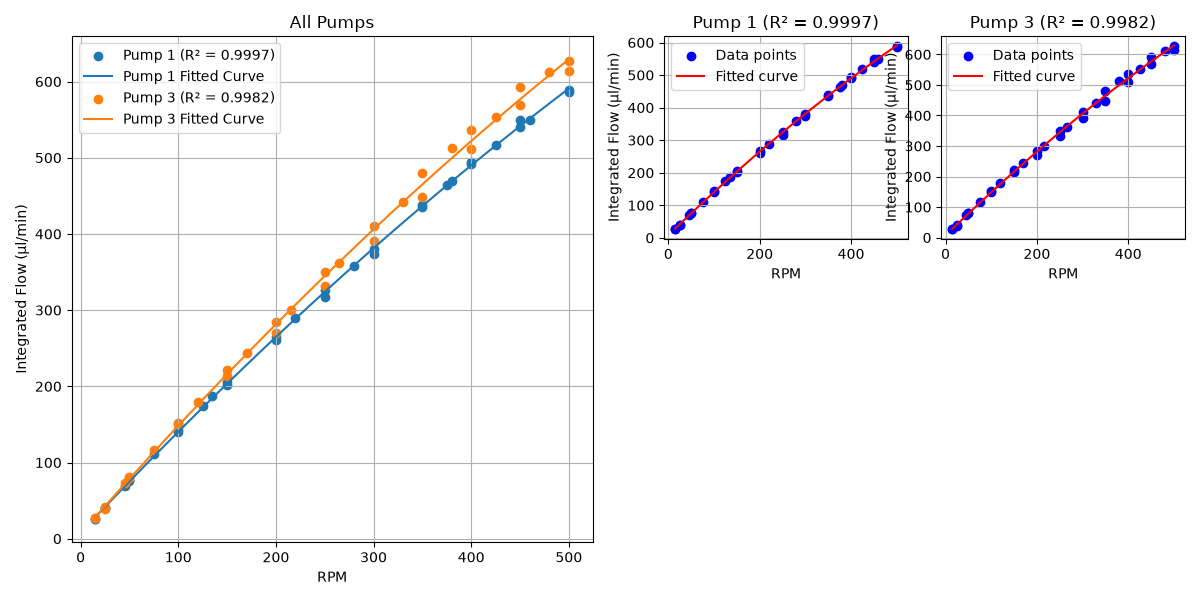

In [ ]:
# set up a 1x2 subplot. One is for all pump plots together,and another subplot is for a plot of each pump's data and fitted curve
plt.close('all')
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# left subplot for all pump plots together
all_plot = fig.add_subplot(gs[0, 0])
all_plot.set_title('Flow Calibration for All Pumps')
all_plot.set_xlabel('RPM')
all_plot.set_ylabel('Integrated Flow (µl/min)')
all_plot.grid(True)

# right subplot for each pump's data and fitted curve
individual_plot = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0, 1], hspace=0.5)
individual_axes_1 = fig.add_subplot(individual_plot[0, 0])
individual_axes_2 = fig.add_subplot(individual_plot[0, 1])
individual_axes_3 = fig.add_subplot(individual_plot[1, 0])
individual_axes_4 = fig.add_subplot(individual_plot[1, 1])
individual_axes = [individual_axes_1, individual_axes_2, individual_axes_3, individual_axes_4]

valid_plot_count = 0
for pump_data in pump_storage:
    pump_x = pump_data.pump_number
    rpm_values = np.asarray(pump_data.rpm_values)
    integrated_flows = np.asarray(pump_data.integrated_flow)

    # rearrange ascending order of rpm_values and integrated_flows for plotting
    sorted_indices = np.argsort(rpm_values)
    rpm_values = rpm_values[sorted_indices]
    integrated_flows = integrated_flows[sorted_indices]

    # Fit least squares polynomial to the data
    coefficients = np.polyfit(rpm_values, integrated_flows, 2)
    pump_data.cooefficients = coefficients

    # Generate a range of rpm values for plotting the fitted curve
    rpm_range = np.linspace(np.min(rpm_values), np.max(rpm_values), 100)
    fitted_flows = np.polyval(coefficients, rpm_range)

    # find r-squared value
    residuals = integrated_flows - np.polyval(coefficients, rpm_values)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((integrated_flows - np.mean(integrated_flows))**2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else np.nan
    pump_data.r_squared = r_squared

    # Plotting the data and fitted curve for each pump in the right subplot
    if valid_plot_count < len(individual_axes):
        ax = individual_axes[valid_plot_count]
        ax.grid(True)
        ax.scatter(rpm_values, integrated_flows, color='blue', label='Data points')
        ax.plot(rpm_range, fitted_flows, color='red', label='Fitted curve')
        ax.set_title(f'Pump {pump_x} (R² = {r_squared:.4f})')
        ax.set_xlabel('RPM')
        ax.set_ylabel('Integrated Flow (µl/min)')
        ax.legend()
        valid_plot_count += 1

    # plotting all pumps together in the left subplot
    all_plot.scatter(rpm_values, integrated_flows, label=f'Pump {pump_x} (R² = {r_squared:.4f})')
    all_plot.plot(rpm_range, fitted_flows, label=f'Pump {pump_x} Fitted Curve')

# Hide any unused individual subplots.
for j in range(valid_plot_count, len(individual_axes)):
    individual_axes[j].set_visible(False)

all_plot.set_title('All Pumps')
all_plot.set_xlabel('RPM')
all_plot.set_ylabel('Integrated Flow (µl/min)')
all_plot.legend()
plt.tight_layout()
plt.show()

# print(f"Fitted polynomial coefficients for Pump {pump_x}: {coefficients}")
# print(f"R-squared value: {r_squared:.4f}")

# # Always use a fresh figure so reruns do not stack previous traces
# plt.close('all')
# fig, ax = plt.subplots()
# ax.scatter(rpm_values, integrated_flows, color='blue', label='Data points')
# ax.plot(rpm_range, fitted_flows, color='red', label='Fitted curve')
# ax.set_title(f'Flow Calibration for Pump {pump_x}')
# ax.set_xlabel('RPM')
# ax.set_ylabel('Integrated Flow (µl/min)')
# ax.legend()
# ax.grid(True)
# fig.tight_layout()
# plt.show()